In [3]:
import torch
print(torch.cuda.is_available())           # True
print(torch.cuda.get_device_name(0))       # NVIDIA GeForce RTX 3060
print(torch.cuda.get_device_properties(0).total_memory / 1e9)  # ~6GB

True
NVIDIA GeForce RTX 3060 Laptop GPU
6.441926656


In [4]:
import torch
import pandas as pd
import numpy as np
from torch.utils.data import Dataset, DataLoader
from transformers import (
    RobertaTokenizer,
    RobertaForSequenceClassification,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from torch.cuda.amp import autocast, GradScaler   # Mixed precision — saves VRAM

In [5]:
# ── Config ──────────────────────────────────────────────
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_NAME = "roberta-base"
MAX_LEN    = 256
BATCH_SIZE = 16
EPOCHS     = 3
LR         = 2e-5
GRAD_ACCUM = 2   # effective batch = 32

print(f"Using: {DEVICE}")


Using: cuda


In [6]:
# ── Dataset class ────────────────────────────────────────
class NewsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer):
        self.encodings = tokenizer(
            list(texts),
            truncation=True,
            padding=True,
            max_length=MAX_LEN,
            return_tensors="pt"
        )
        self.labels = torch.tensor(list(labels), dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids":      self.encodings["input_ids"][idx],
            "attention_mask": self.encodings["attention_mask"][idx],
            "labels":         self.labels[idx]
        }

In [7]:
# ── Load & prep data ─────────────────────────────────────
import pandas as pd
import gc
from sklearn.model_selection import train_test_split

# ── Load with memory optimization ───────────────────────
df = pd.read_csv("WELFake_Dataset.csv", 
                 usecols=["title", "text", "label"],  # skip unnamed index col
                 dtype={"label": "int8"})              # saves memory

print("Loaded shape:", df.shape)
print("Memory:", df.memory_usage(deep=True).sum() / 1e6, "MB")

# ── Clean ────────────────────────────────────────────────
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

# ── Combine title + text ─────────────────────────────────
df["content"] = df["title"].fillna("") + " " + df["text"].fillna("")

# Free memory — drop original columns immediately
df.drop(columns=["title", "text"], inplace=True)
gc.collect()

print("After cleanup shape:", df.shape)
print("Memory after cleanup:", df.memory_usage(deep=True).sum() / 1e6, "MB")

# ── Split ────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    df["content"], df["label"],
    test_size=0.2, random_state=42, stratify=df["label"]
)

# Free full df — no longer needed
del df
gc.collect()

print("Train size:", len(X_train))
print("Test size :", len(X_test))


Loaded shape: (72134, 3)
Memory: 245.316947 MB
After cleanup shape: (63121, 2)
Memory after cleanup: 217.007468 MB
Train size: 50496
Test size : 12625


In [8]:
# ── Tokenizer & model ────────────────────────────────────
tokenizer = RobertaTokenizer.from_pretrained(MODEL_NAME)
model     = RobertaForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2
).to(DEVICE)

train_dataset = NewsDataset(X_train, y_train, tokenizer)
test_dataset  = NewsDataset(X_test,  y_test,  tokenizer)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE)

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

c:\Users\rohit\Documents\college\fake model v2\fakenews\.venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\rohit\.cache\huggingface\hub\models--roberta-base. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.weight       | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
classifier.dense.weight    | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [9]:
# ── Optimizer + scheduler ────────────────────────────────
optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total_steps = (len(train_loader) // GRAD_ACCUM) * EPOCHS

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=total_steps // 10,
    num_training_steps=total_steps
)

scaler = GradScaler()  # Mixed precision scaler

C:\Users\rohit\AppData\Local\Temp\ipykernel_5944\1434373219.py:11: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()  # Mixed precision scaler


In [10]:
# ── Training loop ────────────────────────────────────────
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    optimizer.zero_grad()

    for step, batch in enumerate(train_loader):
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels = batch["labels"].to(DEVICE)

        # Mixed precision forward pass — saves ~1.5GB VRAM
        with autocast():
            outputs = model(input_ids=input_ids,
                           attention_mask=attention_mask,
                           labels=labels)
            loss = outputs.loss / GRAD_ACCUM

        scaler.scale(loss).backward()

        # Gradient accumulation
        if (step + 1) % GRAD_ACCUM == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{EPOCHS} — Loss: {avg_loss:.4f}")

C:\Users\rohit\AppData\Local\Temp\ipykernel_5944\603644304.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 1/3 — Loss: 0.0335
Epoch 2/3 — Loss: 0.0023
Epoch 3/3 — Loss: 0.0006


In [11]:
# ── Evaluation ───────────────────────────────────────────
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)

        with autocast():
            outputs = model(input_ids=input_ids,
                           attention_mask=attention_mask)

        preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(batch["labels"].numpy())

print(f"\nRoBERTa Accuracy: {accuracy_score(all_labels, all_preds):.4f}")
print(classification_report(all_labels, all_preds,
                             target_names=["REAL", "FAKE"]))

# ── Save model ───────────────────────────────────────────
model.save_pretrained("./roberta_fakenews")
tokenizer.save_pretrained("./roberta_fakenews")
print("Model saved!")

C:\Users\rohit\AppData\Local\Temp\ipykernel_5944\2650605023.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():



RoBERTa Accuracy: 0.9992
              precision    recall  f1-score   support

        REAL       1.00      1.00      1.00      6959
        FAKE       1.00      1.00      1.00      5666

    accuracy                           1.00     12625
   macro avg       1.00      1.00      1.00     12625
weighted avg       1.00      1.00      1.00     12625



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved!


In [14]:
def predict_news(text, model, tokenizer, device):
    model.eval()
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=256,
        padding=True
    ).to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    probs = torch.softmax(outputs.logits, dim=1).cpu().numpy()[0]
    pred  = np.argmax(probs)

    return {
        "label":      "FAKE NEWS" if pred == 1 else "REAL NEWS",
        "confidence": round(float(probs[pred]), 4),
        "fake_prob":  round(float(probs[1]), 4),
        "real_prob":  round(float(probs[0]), 4)
    }

# Test it
sample1 = "Scientists confirm chocolate cures all diseases!"
print(predict_news(sample1, model, tokenizer, DEVICE))

sample2= "Donald Trump is dead!!"
print(predict_news(sample2, model, tokenizer, DEVICE))

{'label': 'FAKE NEWS', 'confidence': 0.9993, 'fake_prob': 0.9993, 'real_prob': 0.0007}
{'label': 'FAKE NEWS', 'confidence': 1.0, 'fake_prob': 1.0, 'real_prob': 0.0}


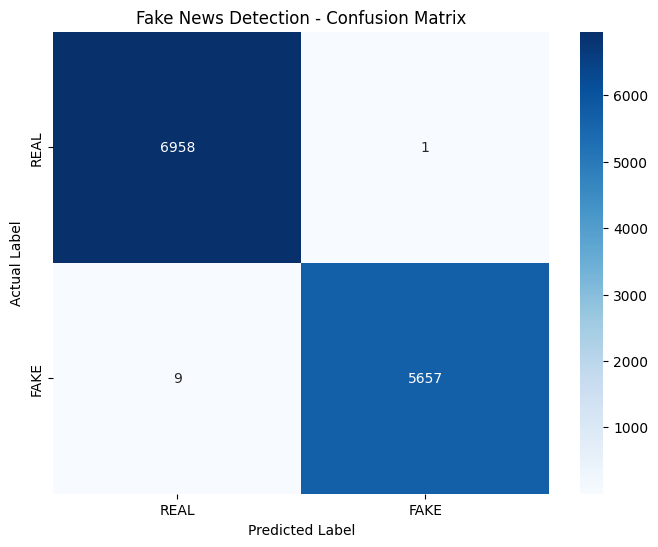

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Generate the confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Plot it using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=["REAL", "FAKE"], 
            yticklabels=["REAL", "FAKE"])
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('Fake News Detection - Confusion Matrix')
plt.show()

Evaluating Model:   0%|          | 0/790 [00:00<?, ?it/s]

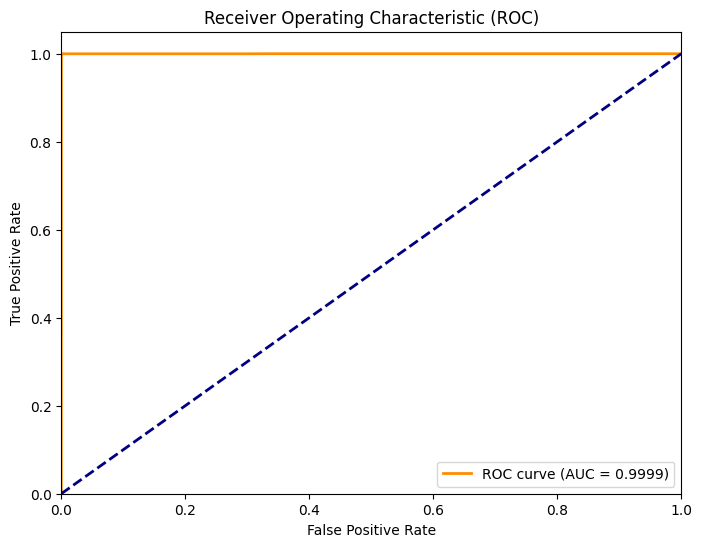

In [16]:
from sklearn.metrics import roc_curve, auc
from tqdm.auto import tqdm
from torch.amp import autocast
import matplotlib.pyplot as plt

# ── 1. Re-run Evaluation to capture probabilities ──────────
model.eval()
all_preds, all_labels, all_probs = [], [], [] # Added all_probs

eval_progress_bar = tqdm(test_loader, desc="Evaluating Model")

with torch.no_grad():
    for batch in eval_progress_bar:
        input_ids      = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)

        with autocast('cuda'):
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)

        # Get probabilities using Softmax
        probs = torch.softmax(outputs.logits, dim=1)
        
        # Save the probability of the "FAKE" class (index 1)
        fake_probs = probs[:, 1].cpu().numpy()
        all_probs.extend(fake_probs)
        
        # Save standard predictions and labels
        preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(batch["labels"].numpy())

# ── 2. Plot the ROC Curve ──────────────────────────────────
# Calculate False Positive Rate, True Positive Rate, and Thresholds
fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Diagonal 50/50 line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()